In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 18

In [74]:
# 3.1
wine = load_wine()
X = wine.data
y = wine.target
nazwy_cech = wine.feature_names
nazwy_klas = wine.target_names
class_counts = np.bincount(y)

print("Liczba próbek:", X.shape[0])
print("Liczba cech:", X.shape[1])
print(f"Cechy: {nazwy_cech}")
print("\nRozkład klas:")
for i, c in enumerate(class_counts):
    print(f"Klasa {i} ({nazwy_klas[i]}): {c}")

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Standaryzacja")
print("Średnie po standaryzacji (pierwsze 5):", X_std.mean(axis=0)[:5])
print("Odch. std po standaryzacji (pierwsze 5):", X_std.std(axis=0)[:5])

Liczba próbek: 178
Liczba cech: 13
Cechy: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Rozkład klas:
Klasa 0 (class_0): 59
Klasa 1 (class_1): 71
Klasa 2 (class_2): 48
Standaryzacja
Średnie po standaryzacji (pierwsze 5): [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17]
Odch. std po standaryzacji (pierwsze 5): [1. 1. 1. 1. 1.]


W związku z tym, że PCA jest wrażliwe na skale zmiennych, może wystąpić sytuacja, że zmienne o większych wartościach zdominują analizę i nie będzie ona poprawna. Należy więc ujednolicić badane dane.

In [75]:
# 3.2
pca = PCA()
X_pca = pca.fit_transform(X_std)

eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cum_ratio = np.cumsum(explained_ratio)

results = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Wartość własna (eigenvalues)": eigenvalues,
    "Wyjaśniona wariancja (%)": explained_ratio * 100,
    "Skumulowana wariancja (%)": cum_ratio * 100
})

print(results)
k_80 = int(np.argmax(cum_ratio >= 0.80) + 1)
print("\nLiczba składowych dla >= 80% wariancji:", k_80)

      PC  Wartość własna (eigenvalues)  Wyjaśniona wariancja (%)  \
0    PC1                      4.732437                 36.198848   
1    PC2                      2.511081                 19.207490   
2    PC3                      1.454242                 11.123631   
3    PC4                      0.924166                  7.069030   
4    PC5                      0.858049                  6.563294   
5    PC6                      0.645282                  4.935823   
6    PC7                      0.554141                  4.238679   
7    PC8                      0.350466                  2.680749   
8    PC9                      0.290512                  2.222153   
9   PC10                      0.252320                  1.930019   
10  PC11                      0.227064                  1.736836   
11  PC12                      0.169724                  1.298233   
12  PC13                      0.103962                  0.795215   

    Skumulowana wariancja (%)  
0              

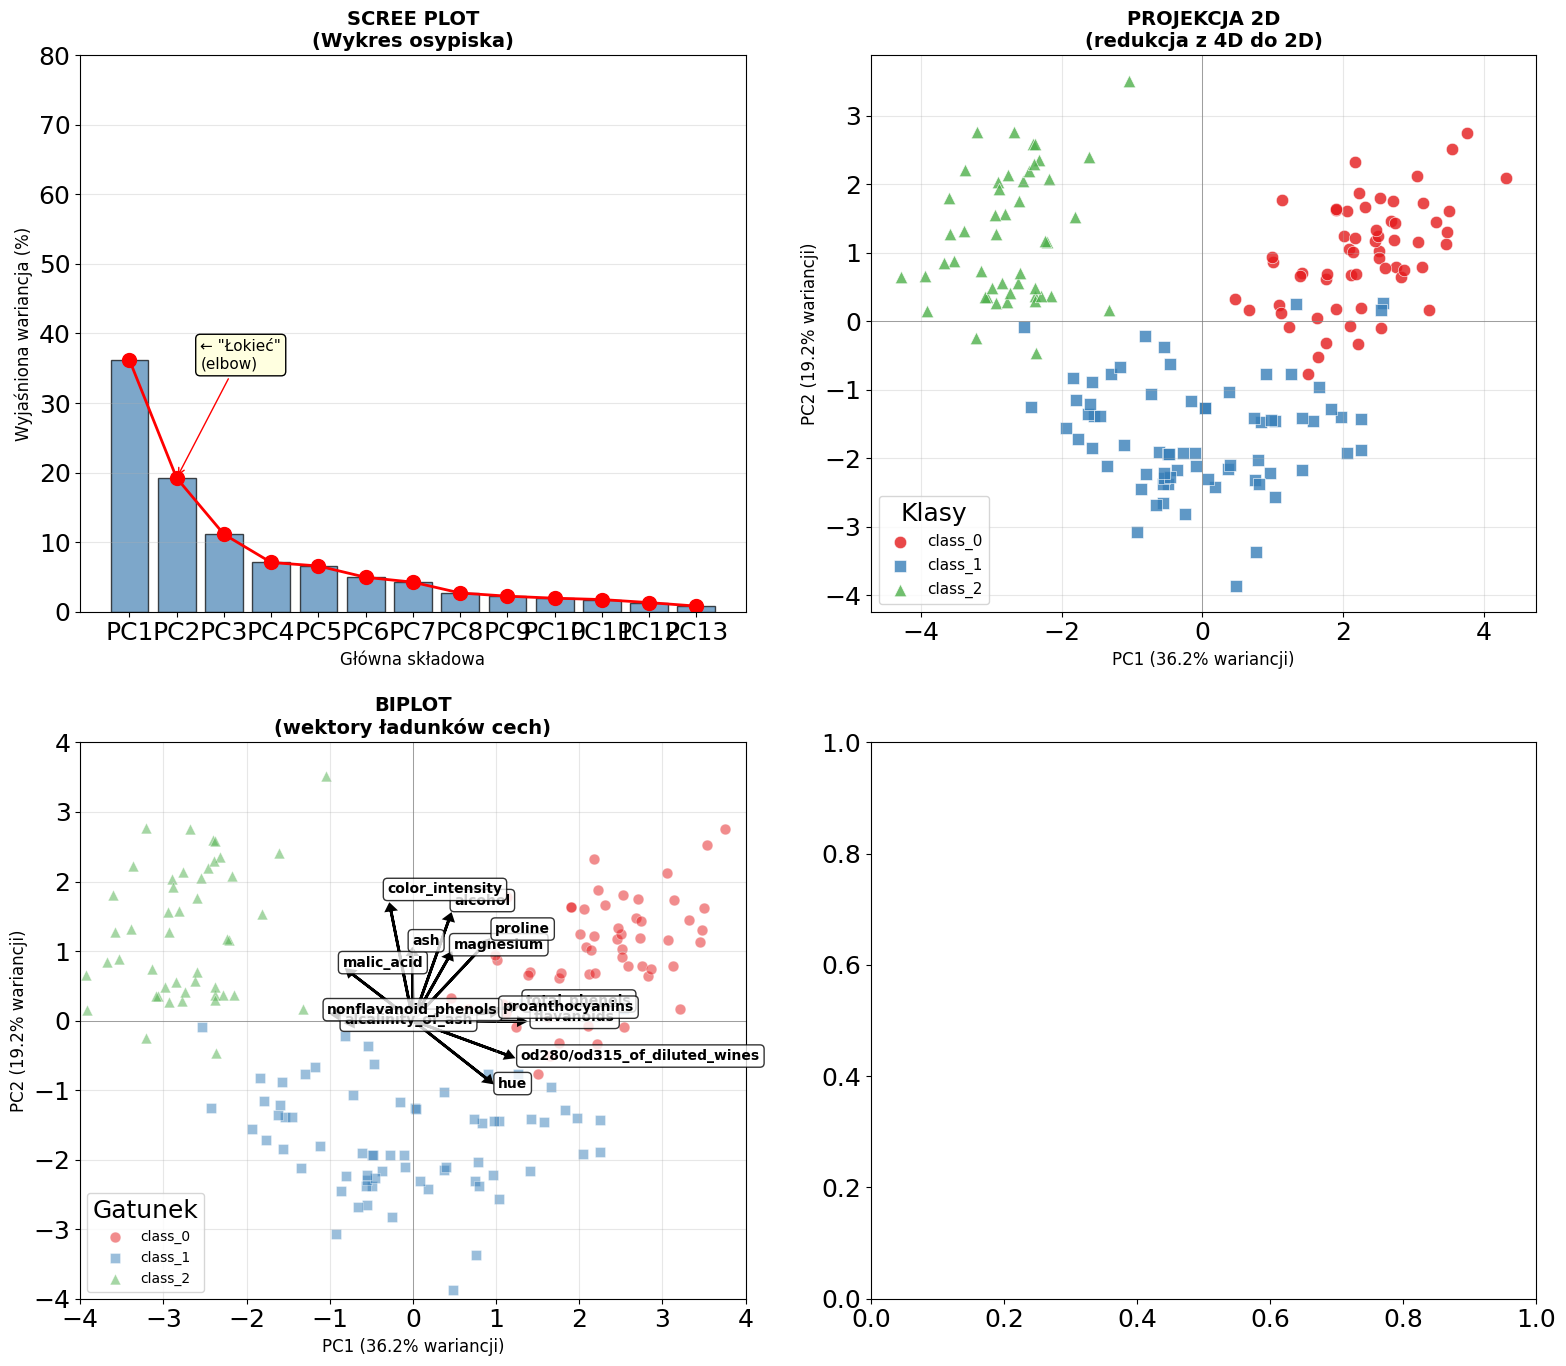

In [76]:
# 3.3
#  Wykres 1: Scree Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

ax1 = axes[0, 0]
pc_labels = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5','PC6','PC7','PC8','PC9','PC10','PC11','PC12','PC13']
variance_pct = pca.explained_variance_ratio_ * 100

bars = ax1.bar(pc_labels, variance_pct, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=10, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=12)
ax1.set_xlabel('Główna składowa', fontsize=12)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 80)

ax1.annotate('← "Łokieć"\n(elbow)', xy=(1, variance_pct[1]), xytext=(1.5, 35),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)

# Wykres 2: Projekcja 2D (PC1 vs PC2)
ax2 = axes[0, 1]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_klas, colors, markers)):
    mask = y == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=80, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.8)

ax2.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax2.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax2.set_title('PROJEKCJA 2D', fontsize=14, fontweight='bold')
ax2.legend(title='Klasy', fontsize=11)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# Wykres 3: Biplot
ax3 = axes[1, 0]

# Punkty danych
for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_klas, colors, markers)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=60, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.5)

# Wektory cech (loadings)
scale = 3
for i, nazwa in enumerate(nazwy_cech):
    if i == 3:
        ax3.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax3.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.65,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax3.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax3.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.15,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax3.set_title('BIPLOT\n(wektory ładunków cech)', fontsize=14, fontweight='bold')
ax3.legend(title='Gatunek', fontsize=10, loc='lower left')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.set_xlim(-4, 4)
ax3.set_ylim(-4, 4)
ax3.grid(True, alpha=0.3)

plt.tight_layout()




In [77]:
# 3.4
print("Ładunki (LOADINGS)")
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=["PC1", "PC2"],
    index=nazwy_cech
)

loadings

Ładunki (LOADINGS)


,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


- Które cechy dominują w PC1? Co reprezentuje ta skłdowa?
  - PC1 opisuje charakterystykę chemiczną wina, dominują cechy świadczące o obecności flawonoidów i fenoli
- Które cechy dominują w PC2?
  - PC2 wskazują cechy świadczące o zawartości alkoholu oraz intensywności barwy
- Czy klasy są dobrze separowalne w 2D?
  - analizując projekcje 2D można stwierdzić, że klasy są dość dobrze separowalne, widać to na podstawie klasy 1 (niebieska) oraz 2 (zielona). Widać jednak możliwe problemy w przypadku separowalności pomiędzy klasą 0 (czerwona) oraz 1 (niebieska).
  Podsumowując klasy ogólnie są dobrze separowalne, lecz nie idealnie.

